In [ ]:
print("hello, ranepa!")

hello, ranepa!


# kaggle

[home-credit-default-risk](https://www.kaggle.com/competitions/home-credit-default-risk/overview)

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files

In [ ]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rushawx","key":"2f6efb7508d546316ee612f2905ac804"}'}

In [ ]:
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets list

ref                                                        title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
yashdevladdha/uber-ride-analytics-dashboard                Uber Data Analytics Dashboard                      17324552  2025-08-08 11:13:42.920000          50210       1108  1.0              
mosapabdelghany/medical-insurance-cost-dataset             Medical Insurance Cost Dataset                        16425  2025-08-24 11:54:36.533000           5427        104  1.0              
zadafiyabhrami/global-crocodile-species-dataset            Global Crocodile Species Dataset                      57473  2025-08-26 08:46:11.950000           4005        124  1.0              
codebynadiia/gdp-per-country-20202025   

In [ ]:
!kaggle competitions download -c 'home-credit-default-risk'

home-credit-default-risk.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip home-credit-default-risk.zip

Archive:  home-credit-default-risk.zip
replace HomeCredit_columns_description.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


# imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading data

In [ ]:
application_train = pd.read_csv('application_train.csv')
application_test = pd.read_csv('application_test.csv')

# q1

Сколько столбцов содержится в таблице application_train?

In [ ]:
application_train.shape[1]

122

# q2

Сколько строк содержится в таблице application_train?

In [ ]:
application_train.shape[0]

307511

# q3

Сколько столбцов типа float64 содержится в таблице application_train?

In [ ]:
application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
65

65

# q4

Сколько уникальных типов контрактов NAME_CONTRACT_TYPE содержится в таблице application_train?

In [ ]:
application_train["NAME_CONTRACT_TYPE"].nunique()

2

# q5

Какой тип контракта NAME_CONTRACT_TYPE наиболее популярен в таблице application_train?

In [ ]:
application_train["NAME_CONTRACT_TYPE"].value_counts(normalize=True)

,proportion
NAME_CONTRACT_TYPE,
Cash loans,0.904787
Revolving loans,0.095213


In [ ]:
"Cash loans"

'Cash loans'

# q6

Какая доля наблюдений приходится на женщин (Gender F) по таблице application_test? Ответ округлите до 4 знаков после запятой.

In [ ]:
np.round(application_test["CODE_GENDER"].value_counts(normalize=True)["F"], 4)

np.float64(0.6704)

In [ ]:
0.6704

0.6704

# q7

Какой минимальный уровень дохода AMT_INCOME_TOTAL фиксируется по данным таблицы application_test?

In [ ]:
application_test["AMT_INCOME_TOTAL"].min()

26941.5

# q8

Какой максимальный уровень дохода AMT_INCOME_TOTAL фиксируется по данным таблицы application_test?

In [ ]:
application_test["AMT_INCOME_TOTAL"].max()

4410000.0

# q9

Какой медианный уровень дохода AMT_INCOME_TOTAL фиксируется по данным таблицы application_test?

In [ ]:
application_test["AMT_INCOME_TOTAL"].median()

157500.0

# q10

Чему равно стандратное отклонение по данным колонки AMT_INCOME_TOTAL таблицы application_test? Ответ округлите до 2 знаков после запятой.

In [ ]:
np.round(application_test["AMT_INCOME_TOTAL"].std(), 2)

np.float64(101522.59)

# q11

Какой максимальный уровень долговой нагрузки (AMT_CREDIT / AMT_INCOME_TOTAL) у мужчин по данным application_train?

In [ ]:
application_train["AMT_CREDIT / AMT_INCOME_TOTAL"] = application_train["AMT_CREDIT"] / application_train["AMT_INCOME_TOTAL"]

In [ ]:
application_train[application_train["CODE_GENDER"] == "M"]["AMT_CREDIT / AMT_INCOME_TOTAL"].max()

29.95

# q12

Какое поле содержит наибольшую долю пропусков в таблице application_train?

In [ ]:
application_train.isna().mean().sort_values(ascending=False)

,0
COMMONAREA_AVG,0.698723
COMMONAREA_MEDI,0.698723
COMMONAREA_MODE,0.698723
NONLIVINGAPARTMENTS_MODE,0.694330
NONLIVINGAPARTMENTS_MEDI,0.694330
...,...
FLAG_DOCUMENT_17,0.000000
FLAG_DOCUMENT_16,0.000000
FLAG_DOCUMENT_15,0.000000
FLAG_DOCUMENT_21,0.000000


In [ ]:
"COMMONAREA_AVG"

'COMMONAREA_AVG'

# q13

Какие два поля имеют наибольшую корреляцию по данным таблицы application_test? Ответ запишите в формате col1 - col2, отсортируйте колонки лексикографически

In [ ]:
df = application_test.corr(numeric_only=True).unstack().reset_index()
df.columns = ["level_0", "level_1", "correlation"]
df[df["level_0"] != df["level_1"]].sort_values("correlation", ascending=False)

,level_0,level_1,correlation
7846,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.999543
8054,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,0.999543
6544,YEARS_BUILD_MEDI,YEARS_BUILD_AVG,0.998818
3632,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998818
3526,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,0.997679
...,...,...,...
11013,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_DOCUMENT_16,NaN
11014,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_DOCUMENT_17,NaN
11016,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_DOCUMENT_19,NaN
11017,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_DOCUMENT_20,NaN


In [ ]:
" - ".join(sorted(["OBS_30_CNT_SOCIAL_CIRCLE", "OBS_60_CNT_SOCIAL_CIRCLE"]))

'OBS_30_CNT_SOCIAL_CIRCLE - OBS_60_CNT_SOCIAL_CIRCLE'

# q14

Какой в среднем доход AMT_INCOME_TOTAL имеют люди с высшим образованием (NAME_EDUCATION_TYPE == "Higher education") по данным таблицы application_train? Ответ округлите до 2 знаков после запятой

In [ ]:
np.round(application_train[application_train["NAME_EDUCATION_TYPE"] == "Higher education"]["AMT_INCOME_TOTAL"].mean(), 2)

np.float64(208652.05)

In [ ]:
208652.05

208652.05

# q15

Какой тип профессии преобладает среди женщин с высшим образованием по данным application_train?

In [ ]:
application_train[(application_train["NAME_EDUCATION_TYPE"] == "Higher education") & (application_train["CODE_GENDER"] == "F")]["OCCUPATION_TYPE"].value_counts(normalize=True)

,proportion
OCCUPATION_TYPE,
Core staff,0.297646
Managers,0.169358
Accountants,0.157503
Sales staff,0.124450
Laborers,0.074800
High skill tech staff,0.073219
Medicine staff,0.027013
Private service staff,0.013605
Secretaries,0.012843


In [ ]:
"Core staff"

'Core staff'

# q16

Посчитайте количество выбросов по графику ящик с усами на данных application_test

In [ ]:
q25 = application_test["AMT_INCOME_TOTAL"].quantile(0.25)
q75 = application_test["AMT_INCOME_TOTAL"].quantile(0.75)

In [ ]:
application_test[(application_test["AMT_INCOME_TOTAL"] < q25) | (application_test["AMT_INCOME_TOTAL"] > q75)].shape[0]

17284

<Axes: ylabel='AMT_INCOME_TOTAL'>

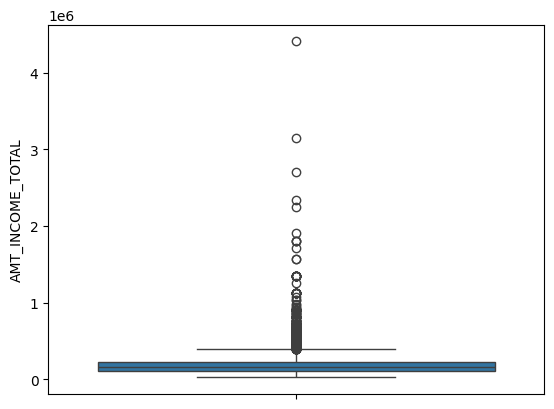

In [ ]:
sns.boxplot(application_test["AMT_INCOME_TOTAL"])

In [ ]:
17284

17284

# q17

Сколько пиков имеет распределение данных по полю AMT_CREDIT по таблице application_test?

<Axes: xlabel='AMT_CREDIT', ylabel='Count'>

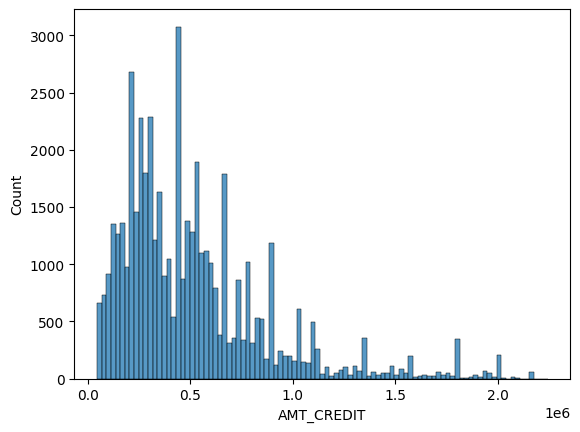

In [ ]:
sns.histplot(application_test["AMT_CREDIT"])

In [ ]:
1

1

# q18

Заработная плата по скольким профессиям больше среднего значения по всей выборке application_train?

In [ ]:
df = application_train.groupby(by=["OCCUPATION_TYPE"])["AMT_INCOME_TOTAL"].mean().sort_values(ascending=False)
sum(df > application_train["AMT_INCOME_TOTAL"].mean())

9

# q19

Какая доля клиентов испытывают трудности с платежами по данным таблицы application_train? (TARGET == 1) Ответ округлите до 4 знаков после запятой.

In [ ]:
np.round(application_train["TARGET"].mean(), 4)

np.float64(0.0807)

# q20

Как распределение CODE_GENDER по тренировочному набору данных application_train соотносятся с тестовым набором application_test? Поставьте: 1, если доля мужчин на тесте выше; -1, если доля мужчин на тесте ниже; 0, если разница лежит в пределах 0.1

In [ ]:
diff = (application_test["CODE_GENDER"] == "M").mean() - (application_train["CODE_GENDER"] == "M").mean()

print(np.round(diff, 4))

if abs(diff) <= 0.1:
  print(0)
elif diff > 0.1:
  print(1)
else:
  print(-1)

-0.012
0


# q21

Обучите модель логистической регрессии на данных Iris. Получите оценку точности классификации. Задайте random_state равный 42. Ответ округлите до 4 знаков после запятой

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression(random_state=42)

In [ ]:
X, y = load_iris(return_X_y=True)

In [ ]:
lr.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
np.round(lr.score(X, y), 4)

np.float64(0.9733)